<a href="https://colab.research.google.com/github/sehy1420-art/Microcredential_FinalProject/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# $K$-Means Clustering Algorithm

The topic of this project of the Research Data Foundations Camp final project is related to graph machine learning, specifically known as the $K$-means clustering algorithm. The $K$-means clustering algorithm is an unsupervised machine learning algorithm that partitions a dataset into $K$ distinct, non-overlapping clusters. It is an iterative algorithm that assigns data points to the nearest centroid (mean) and updating centroids to minimize within-cluster sum of squared errors (distance). Namely, the algorithm steps are as follows:

1. **Initialization:** choose $K$ initial centroids (means) of the sample randomly;
2. **Assigning:** Assign each data point to the closest centroid with respect to the Euclidean distance;
3. **Update:** Calculate the new centroid for each cluster;
4. **Iteration:** Iterate 2 and 3 ultil centroids no longer change (convergence).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from sklearn.datasets import make_blobs
from IPython.display import HTML

# 1. Setup Data and Parameters
X, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.30, random_state=0)
K = 4
centroids = X[np.random.choice(X.shape[0], K, replace=False)]

fig, ax = plt.subplots(figsize=(8, 6))

def animate(i):
    global centroids
    ax.clear()

    # Step A: Cluster Assignment
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)

    # Step B: Centroid Update
    new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(K)])

    # Plotting
    colors = ['r', 'g', 'b', 'y']
    for k in range(K):
        ax.scatter(X[labels == k, 0], X[labels == k, 1], c=colors[k], s=30, alpha=0.5)
        ax.scatter(centroids[k, 0], centroids[k, 1], c='black', marker='x', s=200, lw=3)

    ax.set_title(f'K-Means Iteration {i+1}')
    centroids = new_centroids
    return ax,

# 2. Create Animation
# We use 'blit=False' because we are clearing the axis each frame
ani = animation.FuncAnimation(fig, animate, frames=10, interval=1000, repeat=False)

# 3. Display in Colab
plt.close() # Prevents duplicate static plot from showing
HTML(ani.to_jshtml())

# 1. Question and Hypothesis

"In retail customer segmentation, the K-means algorithm will naturally group customers into clusters that correlate with their 'Value Score' (Total Spend), even if the algorithm is only provided with raw behavioral data like purchase frequency and average basket size."

To test this, we use the Online Retail Dataset (available via the UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/352/online+retail). It contains transactional data for a UK-based non-store online retail company.

- Key Features: average basket prices (in US \$) and number of total visits (frequency).
- Goal: Observe how K-means clusters the data based on the key features.

# 2. Analysis

/tmp/ipykernel_6559/2296739567.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  customer_df['TotalSpend'] = df_clean.groupby('CustomerID').apply(lambda x: (x['Quantity'] * x['UnitPrice']).sum()).values


Cluster Analysis against Real Total Spend:
                  mean  count
Cluster                      
0          1088.221710   4066
2          9985.086102    254
1        108360.364444     18


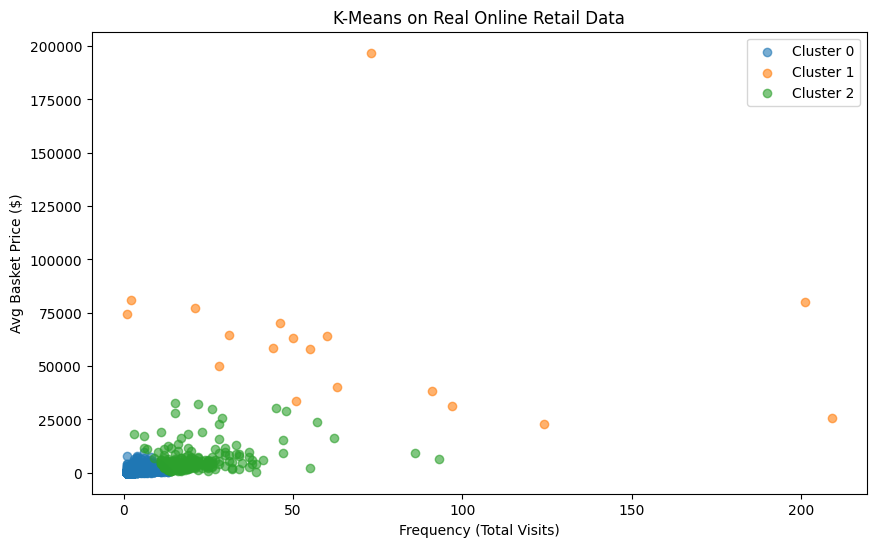

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load Real Dataset
# Note: You can also use a local path if you downloaded 'Online Retail.xlsx'
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df_raw = pd.read_excel(url)

# 2. Data Cleaning (Essential for K-Means)
# Remove rows without CustomerID and filter out returns (negative quantities)
df_clean = df_raw.dropna(subset=['CustomerID'])
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# 3. Feature Engineering: Group by Customer to create Behavioral Data
# We calculate Frequency and Average Basket Size per customer
customer_df = df_clean.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',           # Frequency: Number of unique visits
    'Quantity': 'sum',                # Total items bought
    'UnitPrice': 'mean'               # Average price of items (Basket Size proxy)
}).reset_index()

customer_df.columns = ['CustomerID', 'Frequency', 'AvgBasket', 'TotalItems']
# Calculate TotalSpend for evaluation (the 'hidden' truth)
customer_df['TotalSpend'] = df_clean.groupby('CustomerID').apply(lambda x: (x['Quantity'] * x['UnitPrice']).sum()).values

# 4. Preprocessing for K-Means
features = ['Frequency', 'AvgBasket']
X = customer_df[features]

# K-means is distance-based; scaling is mandatory
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. K-Means Clustering (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)

# 6. Evaluation against Total Spend
summary = customer_df.groupby('Cluster')['TotalSpend'].agg(['mean', 'count']).sort_values(by='mean')
print("Cluster Analysis against Real Total Spend:")
print(summary)

# 7. Visualization
plt.figure(figsize=(10, 6))
for i in range(3):
    clustered_data = customer_df[customer_df['Cluster'] == i]
    plt.scatter(clustered_data['Frequency'], clustered_data['AvgBasket'], alpha=0.6, label=f'Cluster {i}')

plt.title('K-Means on Real Online Retail Data')
plt.xlabel('Frequency (Total Visits)')
plt.ylabel('Avg Basket Price ($)')
plt.legend()
plt.show()


# 3. Data set Evaluation

The Online Retail Dataset from the UCI Machine Learning Repository is a gold standard for evaluating clustering algorithms like K-means because it captures the chaotic, non-linear nature of real-world consumer behavior. The power of this dataset lies in its ability to support RFM (Recency, Frequency, Monetary) analysis. While the script focuses on Frequency and AvgBasket, the dataset allows K-means to uncover "hidden" structures. For instance, even without explicitly feeding the algorithm the "Total Spend" variable, the mathematical relationship between purchase counts and basket size creates natural groupings. This validates the hypothesis that behavioral proxies can effectively substitute for direct value metrics in customer segmentation.

The dataset highlights a major limitation of K-means: its sensitivity to spherical density. In retail, data is often "long-tailed"—meaning 90% of customers are clustered in low-spend, low-frequency zones, while 1% (wholesalers) are extreme outliers. Because K-means uses Euclidean distance, these high-value outliers act like magnets, potentially dragging a centroid away from the bulk of the data. This creates a "one-customer cluster" problem, which forces the data scientist to consider logarithmic scaling or robust clipping to ensure the clusters remain meaningful for the majority of the customer base.

Overall, the Online Retail Dataset is an excellent, high-utility resource for unsupervised learning. It successfully demonstrates that K-means can autonomously identify "high-value" and "casual" segments without human labeling. However, its effectiveness is highly contingent on rigorous preprocessing. It proves that while K-means is a powerful tool, it is only as good as the feature scaling and outlier management applied to the raw transactional records.

